In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express as px
from plotly import graph_objects as go

In [ ]:
df=pd.read_csv('data/gandhinagar_property_apartments_cleaned.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      1304 non-null   str    
 1   Location                  1304 non-null   str    
 2   Price (INR in Lakhs)      1304 non-null   float64
 3   Price_per_sqft            1304 non-null   float64
 4   Area_sqft                 1304 non-null   float64
 5   Description               1203 non-null   str    
 6   Property_URL              1304 non-null   str    
 7   bedrooms                  1302 non-null   float64
 8   bathrooms                 1304 non-null   float64
 9   balconies                 1304 non-null   float64
 10  current_floor             1304 non-null   float64
 11  total_floors              1304 non-null   float64
 12  furnishing_status         1304 non-null   str    
 13  Mapped_Area               1304 non-null   str    
 14  facing             

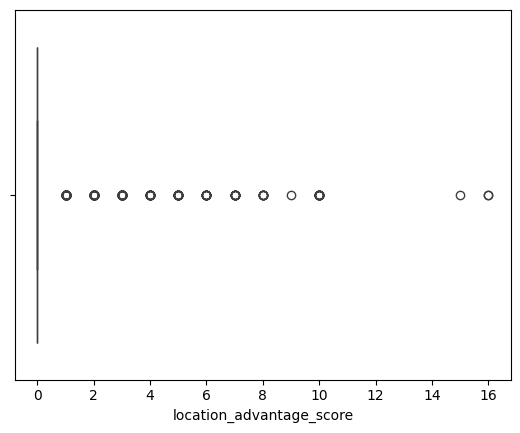

In [28]:
# sns.boxplot(x=df['luxury_score'])
sns.boxplot(x=df['location_advantage_score'])
plt.show()

In [36]:
def luxury_category(score):
    if score <= 0:
        return 'Budget'
    elif score <= 5:
        return 'Semi_Luxury'
    else:
        return 'Luxury'

df['luxury_category'] = df['luxury_score'].apply(luxury_category)

In [37]:
df['luxury_category'].value_counts()

luxury_category
Budget         954
Luxury         207
Semi_Luxury    143
Name: count, dtype: int64

In [44]:
df.groupby('luxury_category')['Price (INR in Lakhs)'].agg(['mean','median'])

,mean,median
luxury_category,,
Budget,89.674455,74.91
Luxury,101.723671,78.00
Semi_Luxury,99.010280,80.00


In [40]:
df['location_advantage_score'].value_counts()

location_advantage_score
0.0     959
1.0      50
2.0      46
3.0      44
4.0      24
5.0      23
10.0     21
6.0      14
7.0      11
8.0       7
16.0      2
15.0      1
9.0       1
Name: count, dtype: int64

In [41]:
def location_category(score):
    if score == 0:
        return 'Poor'
    elif score <= 3:
        return 'Average'
    else:
        return 'Good'

df['location_category'] = df['location_advantage_score'].apply(location_category)

In [42]:
df['location_category'].value_counts()

location_category
Poor       959
Good       205
Average    140
Name: count, dtype: int64

In [43]:
df.groupby('location_category')['Price (INR in Lakhs)'].agg(['mean','median'])

,mean,median
location_category,,
Average,78.667429,65.0
Good,91.854634,75.0
Poor,94.808196,76.0


In [46]:
train_df=df.drop(columns=['Name','Location','Price_per_sqft','Description','Property_URL',
                          'log_price','pps','bedrooms','luxury_category','location_category',
                          'luxury_score','location_advantage_score'])

In [56]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price (INR in Lakhs)    1304 non-null   float64
 1   Area_sqft               1304 non-null   float64
 2   bathrooms               1304 non-null   float64
 3   balconies               1304 non-null   float64
 4   current_floor           1304 non-null   float64
 5   total_floors            1304 non-null   float64
 6   furnishing_status       1304 non-null   str    
 7   Mapped_Area             1304 non-null   str    
 8   facing                  1304 non-null   str    
 9   property_age_bucket     1304 non-null   str    
 10  is_ready_to_move        1304 non-null   int64  
 11  is_built_up_area        1304 non-null   bool   
 12  is_carpet_area          1304 non-null   bool   
 13  is_super_built_up_area  1304 non-null   bool   
 14  property_type           1304 non-null   str    
 15

In [55]:
train_df['floor_ratio']=round(train_df['current_floor'] / train_df['total_floors'],2)

### Linear Feature Selection Techniques

Use one-hot encoding for the categorical features before applying feature selection techniques.

In [57]:
X = train_df.drop(columns=['Price (INR in Lakhs)'])
y = train_df['Price (INR in Lakhs)']

# One-Hot Encoding
X_linear = pd.get_dummies(
    X,
    columns=[
        'furnishing_status',
        'Mapped_Area',
        'facing',
        'property_age_bucket',
        'property_type'
    ],
    drop_first=True,
    dtype=int
)

print(X_linear.shape)
X_linear.head()

(1304, 62)


,Area_sqft,bathrooms,balconies,current_floor,total_floors,is_ready_to_move,is_built_up_area,is_carpet_area,is_super_built_up_area,Bedrooms,...,facing_South-East,facing_South-West,facing_Unknown,facing_West,property_age_bucket_10-20 years,property_age_bucket_5-10 years,property_age_bucket_New,property_age_bucket_Unknown,property_type_builder floor,property_type_penthouse
0,2916.0,3.0,1.0,4.0,8.0,1,False,False,True,3.0,...,0,0,1,0,0,0,1,0,0,0
1,1755.0,3.0,2.0,3.0,7.0,0,False,False,True,3.0,...,0,0,1,0,0,0,1,0,0,0
2,1908.0,3.0,2.0,4.0,8.0,1,False,False,True,3.0,...,0,0,1,0,0,0,1,0,0,0
3,2205.0,2.0,2.0,9.0,13.0,1,False,True,False,3.0,...,0,0,1,0,0,0,1,0,0,0
4,1755.0,3.0,1.0,8.0,13.0,1,False,True,False,3.0,...,0,0,1,0,0,1,0,0,0,0


#### Pearson correlation

In [80]:
pearson_corr = X_linear.corrwith(y).abs().sort_values(ascending=False)

pearson_df = pd.DataFrame({
    'Feature': pearson_corr.index,
    'Pearson': pearson_corr.values
})

pearson_df.head(20)

,Feature,Pearson
0,Area_sqft,0.718624
1,Bedrooms,0.656728
2,bathrooms,0.644726
3,total_floors,0.465506
4,is_ready_to_move,0.385225
5,Mapped_Area_Gift City,0.368234
6,current_floor,0.316721
7,Mapped_Area_Kalol,0.216717
8,balconies,0.206638
9,is_super_built_up_area,0.204156


#### Spearman correlation

In [81]:
spearman_corr = X_linear.corrwith(y, method='spearman').abs().sort_values(ascending=False)

spearman_df = pd.DataFrame({
    'Feature': spearman_corr.index,
    'Spearman': spearman_corr.values
})

spearman_df.head(20)

,Feature,Spearman
0,Bedrooms,0.705761
1,Area_sqft,0.689953
2,bathrooms,0.688490
3,total_floors,0.545885
4,current_floor,0.392137
5,is_ready_to_move,0.366509
6,Mapped_Area_Gift City,0.351224
7,Mapped_Area_Kalol,0.312169
8,Mapped_Area_Vavol,0.275253
9,is_super_built_up_area,0.212161


#### Mutual information regression

In [ ]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(
    X_linear,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X_linear.columns,
    'MI': mi_scores
}).sort_values('MI', ascending=False)

mi_df.head(20)

,Feature,MI
0,Area_sqft,0.748629
9,Bedrooms,0.548837
1,bathrooms,0.526088
4,total_floors,0.291200
3,current_floor,0.211098
10,floor_ratio,0.150714
18,Mapped_Area_Gift City,0.093795
5,is_ready_to_move,0.083664
32,Mapped_Area_Sargasan,0.068519
19,Mapped_Area_Kalol,0.063158


#### F-regression

In [63]:
from sklearn.feature_selection import f_regression

f_scores, p_values = f_regression(X_linear, y)

f_df = pd.DataFrame({
    'Feature': X_linear.columns,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

f_df.head(20)

,Feature,F_Score,P_Value
0,Area_sqft,1390.424955,1.191243e-207
9,Bedrooms,987.400548,9.111664e-162
1,bathrooms,926.201590,4.247106e-154
4,total_floors,360.189917,4.208059e-71
5,is_ready_to_move,226.883614,2.192530e-47
18,Mapped_Area_Gift City,204.240672,3.791796e-43
3,current_floor,145.169016,9.008482e-32
19,Mapped_Area_Kalol,64.163505,2.521453e-15
2,balconies,58.074070,4.838317e-14
8,is_super_built_up_area,56.627147,9.788259e-14


#### Lasso regression

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_linear)

lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=10000
)

lasso.fit(X_scaled, y)

lasso_df = pd.DataFrame({
    'Feature': X_linear.columns,
    'Lasso_Coeff': abs(lasso.coef_)
}).sort_values('Lasso_Coeff', ascending=False)

lasso_df.head(20)

,Feature,Lasso_Coeff
0,Area_sqft,30.180802
18,Mapped_Area_Gift City,20.563941
9,Bedrooms,11.780584
4,total_floors,5.024350
1,bathrooms,4.981680
41,Mapped_Area_Sector 6,2.928506
36,Mapped_Area_Sector 22,2.445931
29,Mapped_Area_Raysan,0.000015
5,is_ready_to_move,0.000000
6,is_built_up_area,0.000000


In [82]:
rank_df = pd.DataFrame(index=X_linear.columns)

rank_df['Pearson'] = pearson_df.set_index('Feature')['Pearson'] \
                               .rank(ascending=False, method='average')

rank_df['Spearman'] = spearman_df.set_index('Feature')['Spearman'] \
                                 .rank(ascending=False, method='average')

rank_df['MI'] = mi_df.set_index('Feature')['MI'] \
                     .rank(ascending=False, method='average')

rank_df['F_Score'] = f_df.set_index('Feature')['F_Score'] \
                         .rank(ascending=False, method='average')

rank_df['Lasso'] = lasso_df.set_index('Feature')['Lasso_Coeff'] \
                           .rank(ascending=False, method='average')

In [84]:
rank_df['Average_Rank'] = rank_df.mean(axis=1)

final_linear_ranking = rank_df.sort_values('Average_Rank')

final_linear_ranking.head(60)

,Pearson,Spearman,MI,F_Score,Lasso,Average_Rank
Area_sqft,1.0,2.0,1.0,1.0,1.0,1.2
Bedrooms,2.0,1.0,2.0,2.0,3.0,2.0
bathrooms,3.0,3.0,3.0,3.0,5.0,3.4
total_floors,4.0,4.0,4.0,4.0,4.0,4.0
Mapped_Area_Gift City,6.0,7.0,7.0,6.0,2.0,5.6
is_ready_to_move,5.0,6.0,8.0,5.0,35.5,11.9
current_floor,7.0,5.0,5.0,7.0,35.5,11.9
Mapped_Area_Kalol,8.0,8.0,10.0,8.0,35.5,13.9
balconies,9.0,12.0,12.0,9.0,35.5,15.5
is_super_built_up_area,10.0,10.0,16.0,10.0,35.5,16.3


### Non-linear feature selection techniques

For the non-linear phase, use Ordinal Encoding for categorical features.

In [86]:
from sklearn.preprocessing import OrdinalEncoder

X = train_df.drop(columns=['Price (INR in Lakhs)'])
y = train_df['Price (INR in Lakhs)']

cat_cols = [
    'furnishing_status',
    'Mapped_Area',
    'facing',
    'property_age_bucket',
    'property_type'
]

X_nonlinear = X.copy()

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_nonlinear[cat_cols] = encoder.fit_transform(X_nonlinear[cat_cols])

X_nonlinear.head()

,Area_sqft,bathrooms,balconies,current_floor,total_floors,furnishing_status,Mapped_Area,facing,property_age_bucket,is_ready_to_move,is_built_up_area,is_carpet_area,is_super_built_up_area,property_type,Bedrooms,floor_ratio
0,2916.0,3.0,1.0,4.0,8.0,0.0,19.0,8.0,3.0,1,False,False,True,0.0,3.0,0.50
1,1755.0,3.0,2.0,3.0,7.0,0.0,13.0,8.0,3.0,0,False,False,True,0.0,3.0,0.43
2,1908.0,3.0,2.0,4.0,8.0,0.0,16.0,8.0,3.0,1,False,False,True,0.0,3.0,0.50
3,2205.0,2.0,2.0,9.0,13.0,0.0,16.0,8.0,3.0,1,False,True,False,0.0,3.0,0.69
4,1755.0,3.0,1.0,8.0,13.0,3.0,14.0,8.0,2.0,1,False,True,False,0.0,3.0,0.62


#### Random Forest Importance

In [87]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_nonlinear, y)

rf_df = pd.DataFrame({
    'Feature': X_nonlinear.columns,
    'RF_Importance': rf.feature_importances_
}).sort_values('RF_Importance', ascending=False)

rf_df.head(20)

,Feature,RF_Importance
14,Bedrooms,0.447378
0,Area_sqft,0.219066
4,total_floors,0.195470
6,Mapped_Area,0.028998
1,bathrooms,0.027672
3,current_floor,0.023532
15,floor_ratio,0.018895
2,balconies,0.008131
8,property_age_bucket,0.006668
7,facing,0.005657


#### Extra Trees Importance

In [88]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

et.fit(X_nonlinear, y)

et_df = pd.DataFrame({
    'Feature': X_nonlinear.columns,
    'ET_Importance': et.feature_importances_
}).sort_values('ET_Importance', ascending=False)

et_df.head(20)

,Feature,ET_Importance
14,Bedrooms,0.267680
0,Area_sqft,0.204955
1,bathrooms,0.172611
4,total_floors,0.149243
6,Mapped_Area,0.050412
9,is_ready_to_move,0.045308
3,current_floor,0.026061
15,floor_ratio,0.016115
2,balconies,0.014532
7,facing,0.010967


#### Gradient Boosting Importance

In [89]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42
)

gbr.fit(X_nonlinear, y)

gbr_df = pd.DataFrame({
    'Feature': X_nonlinear.columns,
    'GBR_Importance': gbr.feature_importances_
}).sort_values('GBR_Importance', ascending=False)

gbr_df.head(20)

,Feature,GBR_Importance
14,Bedrooms,0.384678
0,Area_sqft,0.297145
4,total_floors,0.221101
6,Mapped_Area,0.031106
1,bathrooms,0.023423
3,current_floor,0.018777
15,floor_ratio,0.006733
2,balconies,0.004687
10,is_built_up_area,0.004341
7,facing,0.002656


#### Permutation Importance

In [90]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_nonlinear,
    y,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_nonlinear.columns,
    'Permutation': perm.importances_mean
}).sort_values('Permutation', ascending=False)

perm_df.head(20)

,Feature,Permutation
14,Bedrooms,0.642052
0,Area_sqft,0.503555
4,total_floors,0.410187
6,Mapped_Area,0.049079
1,bathrooms,0.034550
3,current_floor,0.023751
15,floor_ratio,0.017889
2,balconies,0.008271
11,is_carpet_area,0.006923
8,property_age_bucket,0.006754


#### Mutual Information

In [72]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(
    X_nonlinear,
    y,
    random_state=42
)

mi_nonlinear_df = pd.DataFrame({
    'Feature': X_nonlinear.columns,
    'MI': mi_scores
}).sort_values('MI', ascending=False)

mi_nonlinear_df.head(20)

,Feature,MI
0,Area_sqft,0.754842
14,Bedrooms,0.571013
1,bathrooms,0.513175
6,Mapped_Area,0.302034
4,total_floors,0.281274
3,current_floor,0.188964
15,floor_ratio,0.146083
9,is_ready_to_move,0.078117
8,property_age_bucket,0.065938
7,facing,0.044488


In [74]:
!pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 2.1 MB/s eta 0:00:18
   - -------------------------------------- 1.3/38.1 MB 2.5 MB/s eta 0:00:15
   -- ------------------------------------- 2.1/38.1 MB 2.7 MB/s eta 0:00:14
   --- ------------------------------------ 3.1/38.1 MB 3.2 MB/s eta 0:00:11
   ---- ----------------------------------- 4.5/38.1 MB 3.6 MB/s eta 0:00:10
   ------ --------------------------------- 5.8/38.1 MB 4.0 MB/s eta 0:00:09
   ------- -------------------------------- 6.8/38.1 MB 4.1 MB/s eta 0:00:08
   ------- -------------------------------- 7.6/38.1 MB 4.2 MB/s eta 0:00:08
   --------- ------------------------------ 8.9/38.1 MB 4.3 MB/s eta 0:00:07
   ---------- ----------------------------- 10.2/38.1 MB 4.5 MB/s eta 0:00:07
   ------------ --------------------------- 11.5/38.1 MB 4.7 MB/s eta 0:00:06
   --------


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### SHAP

In [91]:
import shap
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_nonlinear, y)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_nonlinear)

shap_importance = np.abs(shap_values).mean(axis=0)

fi_shap = pd.DataFrame({
    'feature': X_nonlinear.columns,
    'shap_importance': shap_importance
}).sort_values(
    by='shap_importance',
    ascending=False
)

fi_shap

,feature,shap_importance
14,Bedrooms,21.527542
0,Area_sqft,15.926938
4,total_floors,14.441199
6,Mapped_Area,2.821505
1,bathrooms,1.660126
3,current_floor,1.525673
15,floor_ratio,1.060359
11,is_carpet_area,0.690886
8,property_age_bucket,0.573165
2,balconies,0.464724


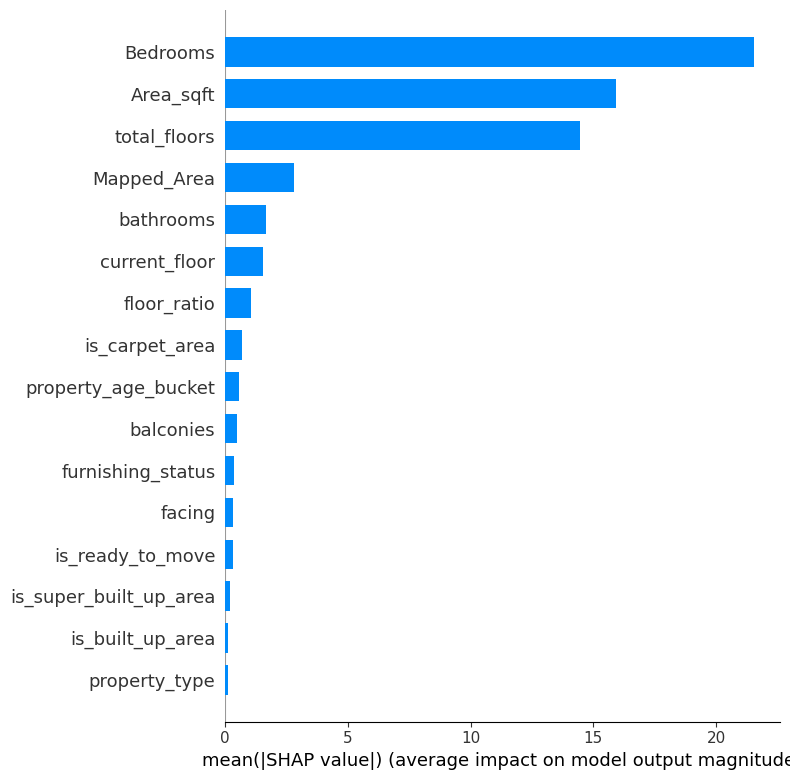

In [92]:
shap.summary_plot(
    shap_values,
    X_nonlinear,
    plot_type='bar'
)

In [ ]:
from sklearn.feature_selection import RFE

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# RFE
rfe = RFE(
    estimator=rf,
    n_features_to_select=1, 
    step=1
)

rfe.fit(X_nonlinear, y)


fi_rfe = pd.DataFrame({
    'feature': X_nonlinear.columns,
    'rfe_rank': rfe.ranking_
})

fi_rfe['rfe_score'] = 1 / fi_rfe['rfe_rank']

fi_rfe = fi_rfe.sort_values(
    by='rfe_rank',
    ascending=True
)

fi_rfe

,feature,rfe_rank,rfe_score
0,Area_sqft,1,1.000000
14,Bedrooms,2,0.500000
4,total_floors,3,0.333333
6,Mapped_Area,4,0.250000
3,current_floor,5,0.200000
1,bathrooms,6,0.166667
15,floor_ratio,7,0.142857
2,balconies,8,0.125000
8,property_age_bucket,9,0.111111
7,facing,10,0.100000


In [93]:
nonlinear_df = pd.DataFrame({
    'feature': X_nonlinear.columns
})

nonlinear_df = nonlinear_df.merge(
    rf_df[['Feature','RF_Importance']],
    left_on='feature',
    right_on='Feature',
    how='left'
).drop(columns='Feature')

nonlinear_df = nonlinear_df.merge(
    et_df[['Feature','ET_Importance']],
    left_on='feature',
    right_on='Feature',
    how='left'
).drop(columns='Feature')

nonlinear_df = nonlinear_df.merge(
    gbr_df[['Feature','GBR_Importance']],
    left_on='feature',
    right_on='Feature',
    how='left'
).drop(columns='Feature')

nonlinear_df = nonlinear_df.merge(
    perm_df[['Feature','Permutation']],
    left_on='feature',
    right_on='Feature',
    how='left'
).drop(columns='Feature')

nonlinear_df = nonlinear_df.merge(
    fi_shap[['feature','shap_importance']],
    on='feature',
    how='left'
)

nonlinear_df = nonlinear_df.merge(
    fi_rfe[['feature','rfe_rank']],
    on='feature',
    how='left'
)

nonlinear_df.head()

,feature,RF_Importance,ET_Importance,GBR_Importance,Permutation,shap_importance,rfe_rank
0,Area_sqft,0.219066,0.204955,0.297145,0.503555,15.926938,1
1,bathrooms,0.027672,0.172611,0.023423,0.034550,1.660126,6
2,balconies,0.008131,0.014532,0.004687,0.008271,0.464724,8
3,current_floor,0.023532,0.026061,0.018777,0.023751,1.525673,5
4,total_floors,0.195470,0.149243,0.221101,0.410187,14.441199,3


In [94]:
rank_df = pd.DataFrame()

rank_df['feature'] = nonlinear_df['feature']

rank_df['RF_rank'] = nonlinear_df['RF_Importance'] \
                        .rank(ascending=False)

rank_df['ET_rank'] = nonlinear_df['ET_Importance'] \
                        .rank(ascending=False)

rank_df['GBR_rank'] = nonlinear_df['GBR_Importance'] \
                        .rank(ascending=False)

rank_df['Permutation_rank'] = nonlinear_df['Permutation'] \
                                .rank(ascending=False)

rank_df['SHAP_rank'] = nonlinear_df['shap_importance'] \
                            .rank(ascending=False)

rank_df['RFE_rank'] = nonlinear_df['rfe_rank']

In [95]:
rank_cols = [
    'RF_rank',
    'ET_rank',
    'GBR_rank',
    'Permutation_rank',
    'SHAP_rank',
    'RFE_rank'
]

rank_df['Average_Rank'] = rank_df[rank_cols].mean(axis=1)

final_nonlinear_ranking = rank_df.sort_values(
    'Average_Rank'
)

final_nonlinear_ranking

,feature,RF_rank,ET_rank,GBR_rank,Permutation_rank,SHAP_rank,RFE_rank,Average_Rank
14,Bedrooms,1.0,1.0,1.0,1.0,1.0,2,1.166667
0,Area_sqft,2.0,2.0,2.0,2.0,2.0,1,1.833333
4,total_floors,3.0,4.0,3.0,3.0,3.0,3,3.166667
6,Mapped_Area,4.0,5.0,4.0,4.0,4.0,4,4.166667
1,bathrooms,5.0,3.0,5.0,5.0,5.0,6,4.833333
3,current_floor,6.0,7.0,6.0,6.0,6.0,5,6.000000
15,floor_ratio,7.0,8.0,7.0,7.0,7.0,7,7.166667
2,balconies,8.0,9.0,8.0,8.0,10.0,8,8.500000
8,property_age_bucket,9.0,11.0,12.0,10.0,9.0,9,10.000000
7,facing,10.0,10.0,10.0,11.0,12.0,10,10.500000


In [97]:
from sklearn.model_selection import cross_val_score

rf_all = RandomForestRegressor(n_estimators=100, random_state=42)

scores_all = cross_val_score(rf_all, X_nonlinear, y, cv=5, scoring='r2')
print(f"R² (all columns): {scores_all.mean():.4f} (+/- {scores_all.std():.4f})")


columns_to_drop = ['property_type', 'floor_ratio']

X_reduced = X_nonlinear.drop(columns=columns_to_drop, errors='ignore')
rf_reduced = RandomForestRegressor(n_estimators=100, random_state=42)

scores_reduced = cross_val_score(rf_reduced, X_reduced, y, cv=5, scoring='r2')
print(f"R² (without {columns_to_drop}): {scores_reduced.mean():.4f} (+/- {scores_reduced.std():.4f})")

R² (all columns): 0.7266 (+/- 0.0913)
R² (without ['property_type', 'floor_ratio']): 0.7253 (+/- 0.0927)


In [98]:
export_df = X_nonlinear.drop(columns=['property_type', 'floor_ratio'])
export_df['price'] = y  

In [99]:
export_df.to_csv('gandhinagar_property_feature_selection.csv', index=False)

In [100]:
export_df.head()

,Area_sqft,bathrooms,balconies,current_floor,total_floors,furnishing_status,Mapped_Area,facing,property_age_bucket,is_ready_to_move,is_built_up_area,is_carpet_area,is_super_built_up_area,Bedrooms,price
0,2916.0,3.0,1.0,4.0,8.0,0.0,19.0,8.0,3.0,1,False,False,True,3.0,126.00
1,1755.0,3.0,2.0,3.0,7.0,0.0,13.0,8.0,3.0,0,False,False,True,3.0,51.99
2,1908.0,3.0,2.0,4.0,8.0,0.0,16.0,8.0,3.0,1,False,False,True,3.0,97.00
3,2205.0,2.0,2.0,9.0,13.0,0.0,16.0,8.0,3.0,1,False,True,False,3.0,125.00
4,1755.0,3.0,1.0,8.0,13.0,3.0,14.0,8.0,2.0,1,False,True,False,3.0,79.00
